In [ ]:
# Se importan todas las librerías necesarias
import pandas as pd
import seaborn as sns
import numpy as np  
from matplotlib import pyplot as plt
import pickle

# Importante poner para que se muestren los gráficos
%matplotlib inline

# Semilla que se usará siempre para garantizar reproducibilidad
semilla = 123

# Directorio con los ficheros
dir_datasets = "./VulkanSimTrain/"

In [5]:
nombres_escenas = ["BATH", "BUNNY", "CAR", "CHSNT", "CRNVL", "FOX", "FRST", "LANDS", "PARK", "PARTY", "REF", "ROBOT", "SHIP", "SPNZA", "SPRNG", "WKND"]

datos = dict()

for nombre in nombres_escenas:
    datos[nombre] = pd.read_csv(dir_datasets+nombre+"-frame0.txt",sep=",",header=None,names=["ID","Cycle","Address","IP","Cache_hit"])


KeyboardInterrupt: 

In [ ]:
for nombre in nombres_escenas:
    print(f"Escena: {nombre}")
    print()
    print(datos[nombre].head())
    print("-"*80)

In [ ]:
for nombre in nombres_escenas:
    print(f"Escena: {nombre}")
    print()
    print(datos[nombre].dtypes)
    print("-"*80)

In [ ]:
# Se pasa la columna Address de hexadecimal a decimal
for nombre in nombres_escenas:
    print("Escena",nombre)
    print()
    datos[nombre]["Address"] = datos[nombre]["Address"].apply(lambda x: int(str(x), 16))
    print("-"*80)

In [ ]:
# Se crea la columna Block_address dividiendo los valores de la
# columna Address entre 128
for nombre in nombres_escenas:
    print("Escena",nombre)
    print()
    datos[nombre]['Block_address'] = datos[nombre]['Address'].apply(lambda x: x//128)
    print("-"*80)


In [ ]:
# Se pasa la columna IP de hexadecimal a decimal, asignando -1 a los valores ffffffffffffffff
for nombre in nombres_escenas:
    print("Escena",nombre)
    print()
    datos[nombre]['IP'] = datos[nombre]['IP'].apply(lambda x: int(x, 16) if x != "ffffffffffffffff" else -1)
    print("-"*80)

In [ ]:
# Se crea la columna Page_address dividiendo los valores de la
# columna Address entre 4096
for nombre in nombres_escenas:
    print("Escena",nombre)
    print()
    datos[nombre]['Page_address'] = datos[nombre]['Address'].apply(lambda x: x//4096)
    print("-"*80)

In [ ]:
# Se crea la columna Delta, que muestra, para cada Block_address,
# la diferencia con el Block_address anterior
# datos['Delta'] = datos['Block_address'].diff().fillna(0).astype(int)

In [ ]:
datos["ROBOT"].head()

In [ ]:
datos["ROBOT"].dtypes

In [ ]:
datos["ROBOT"].describe()

In [ ]:
# Función para mostrar un histograma de una columna
def mostrar_columna(escena:str, columna:str, limite_absoluto:int = None):
    plt.figure(figsize=(8,5))
    if limite_absoluto is not None:
        sns.histplot(data=datos[escena][abs(datos[escena].Page_address_delta) < limite_absoluto], x=columna, bins=100)
    else:
        sns.histplot(data=datos[escena], x=columna, bins=100)
    plt.title(f'Distribución de {columna} para {escena}')
    plt.xlabel(columna)
    plt.ylabel('Recuento')
    plt.ticklabel_format(style="plain")
    plt.show()

In [ ]:
for escena in nombres_escenas:
    next_page_same_counter = 0
    next_page_different_counter = 0

    k = 5

    for i in range(len(datos[escena])-k):
        if datos[escena]["Page_address"][i] == datos[escena]["Page_address"][i+k]:
            next_page_same_counter+=1
        else:
            next_page_different_counter+=1

    print(f"Datos para la escena {escena}:")
    print(f"Saltos a la misma página: {next_page_same_counter} ({100*next_page_same_counter/(next_page_same_counter+next_page_different_counter)}%)")
    print(f"Saltos a otra página: {next_page_different_counter} ({100*next_page_different_counter/(next_page_same_counter+next_page_different_counter)}%)")
    print("="*80)

In [ ]:
for escena in nombres_escenas:
    mostrar_columna(escena,"Page_address")

In [ ]:
for escena in nombres_escenas:
    num_paginas_unicas = datos[escena]["Page_address"].nunique()
    print(f'Número de páginas únicas en la escena {escena}: {num_paginas_unicas} ({100*num_paginas_unicas/datos[escena]["Page_address"].count()}%)')

In [ ]:
historias = [1,2,3,4,5,6,7,8,9,10]

# La clave es la historia. El valor es una lista con los
# porcentajes para cada escena
porcentaje_predicciones_correctas = dict()

for historia in historias:
    print(f"HISTORIA {historia}")
    print("="*20)

    porcentaje_predicciones_correctas[historia] = []

    for escena in nombres_escenas:
        ptt = dict()

        k = 5

        predicciones_correctas = 0
        predicciones_erroneas = 0

        for i in range(historia-1,len(datos[escena])-k):

            paginas_historia = tuple(datos[escena]["Page_address"][i-(historia-1):i+1])

            if paginas_historia in ptt:
                pagina_predicha = ptt[paginas_historia]
            else:
                pagina_predicha = paginas_historia[-1]

            if datos[escena]["Page_address"][i+k] == pagina_predicha:
                predicciones_correctas+=1
            else:
                predicciones_erroneas+=1

            ptt[paginas_historia] = datos[escena]["Page_address"][i+k]

        print(f"Predicciones correctas en la escena {escena}: {predicciones_correctas} ({100*predicciones_correctas/(predicciones_correctas+predicciones_erroneas)}%)")
        porcentaje_predicciones_correctas[historia].append(100*predicciones_correctas/(predicciones_correctas+predicciones_erroneas))
    print()

In [ ]:
with open('porcentaje_predicciones_correctas_direcciones_absolutas.p', 'wb') as fp:
    pickle.dump(porcentaje_predicciones_correctas, fp, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
with open('porcentaje_predicciones_correctas_direcciones_absolutas.p', 'rb') as fp:
    porcentaje_predicciones_correctas = pickle.load(fp)

In [8]:
# Source - https://stackoverflow.com/a
# Posted by willeM_ Van Onsem, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-19, License - CC BY-SA 4.0

import numpy as np

def geo_mean(iterable):
    a = np.array(iterable)
    return a.prod()**(1.0/len(a))

In [9]:
for h in porcentaje_predicciones_correctas.keys():
    media_geometrica = geo_mean(porcentaje_predicciones_correctas[h])
    porcentaje_predicciones_correctas[h].append(media_geometrica)
    print(f"Media geométrica con historia {h}: {media_geometrica}")

Media geométrica con historia 1: 6.907732007191023
Media geométrica con historia 2: 6.475400818624385
Media geométrica con historia 3: 6.67636706259565
Media geométrica con historia 4: 6.423141023814328
Media geométrica con historia 5: 6.321272805114638
Media geométrica con historia 6: 6.261778448673865
Media geométrica con historia 7: 6.21625382343466
Media geométrica con historia 8: 6.192995289558006
Media geométrica con historia 9: 6.177604555663948
Media geométrica con historia 10: 6.164121092234999


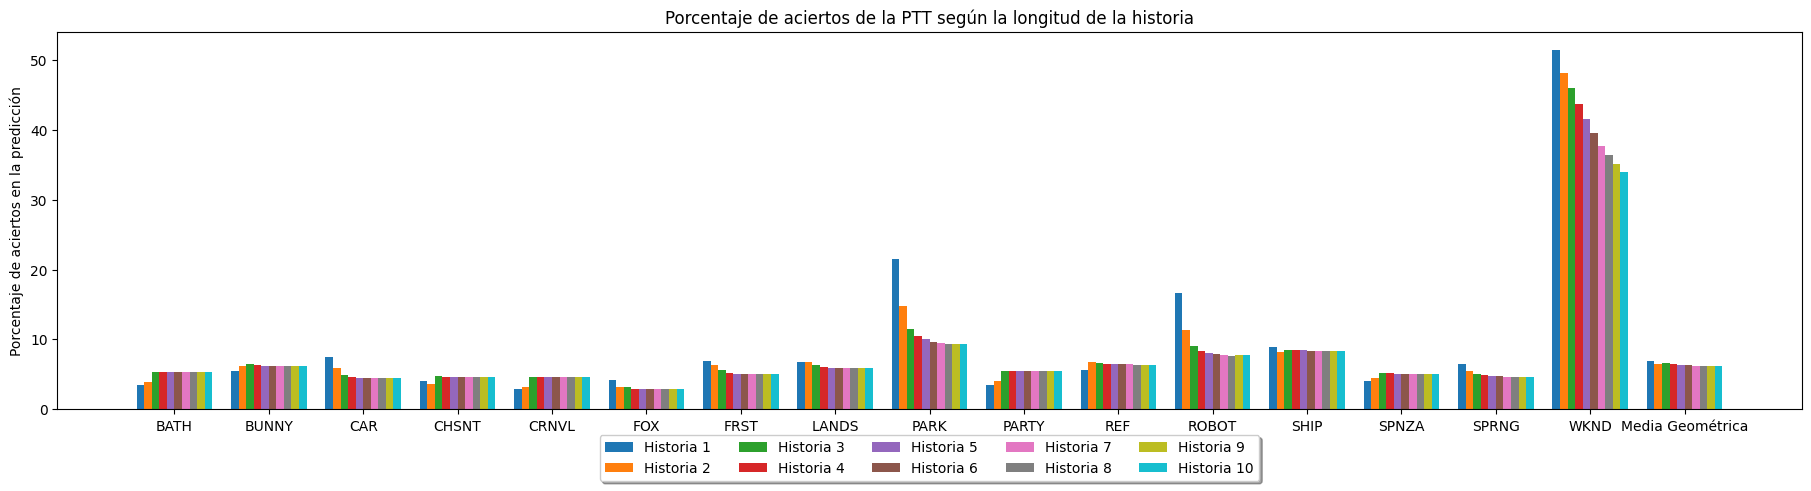

In [11]:
import matplotlib.pyplot as plt
import numpy as np

nombres_escenas = ["BATH", "BUNNY", "CAR", "CHSNT", "CRNVL", "FOX", "FRST", "LANDS", "PARK", "PARTY", "REF", "ROBOT", "SHIP", "SPNZA", "SPRNG", "WKND", "Media Geométrica"]

# Localización de cada etiqueta
x = np.arange(len(nombres_escenas))

# Anchura de las barras
width = 0.08

multiplier = 0

fig, ax = plt.subplots(layout='constrained')

fig.set_figwidth(18)

for historia, medidas in porcentaje_predicciones_correctas.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, medidas, width, label=f"Historia {historia}")
    #ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Porcentaje de aciertos en la predicción')
ax.set_title('Porcentaje de aciertos de la PTT según la longitud de la historia')
ax.set_xticks(x + width*4.5, nombres_escenas)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

plt.show()